In [9]:
import pandas as pd 
import mplfinance as mpf
import matplotlib.pyplot as plt
from datetime import date

from mps.sys import cfg, msg, MPF_STYLE
from mps.sys.dataio import LocalParquetStore, HistoricalDataLoader

In [10]:
ticker, start, end = "005930", date(2025, 1, 1), date(2025, 12, 31)

In [11]:
store = LocalParquetStore()

  = base_dir: [None], self._base_dir: [/home/freeman/projects/mps/data/store]


In [12]:
loader = HistoricalDataLoader(store)
bars = loader.load(ticker, start, end)

  = store: [<mps.sys.dataio._store.LocalParquetStore object at 0x776cbd514550>], self._store: [<mps.sys.dataio._store.LocalParquetStore object at 0x776cbd514550>]
  = 처리 일시: 2025-01-01 00:00:00+09:00 ~ 2025-12-31 23:59:59.999999+09:00
  = store filepath: [/home/freeman/projects/mps/data/store/005930/minute_bars.parquet]
  = 불러올 대상 날짜: [2025-01-01 00:00:00+09:00 ~ 2025-12-31 23:59:59.999999+09:00], Mask: [[ True  True  True ...  True  True  True]]
  = 불러온 데이터프레임 크기: [660660]
  = 리턴할 데이터 크기: [94380]


In [13]:
df = pd.DataFrame([{
    "timestamp": bar.timestamp, 
    "open": bar.open, 
    "high": bar.high,
    "low": bar.low,
    "close": bar.close,
    "volume": bar.volume,
} for bar in bars]).set_index("timestamp")

In [14]:
print(f"봉 수: {len(df)}, {df.size}")
print(f"기 간: {df.index[0]} ~ {df.index[-1]}")
df.head()

봉 수: 94380, 471900
기 간: 2025-01-02 09:00:00+09:00 ~ 2025-12-30 15:29:00+09:00


,open,high,low,close,volume
timestamp,,,,,
2025-01-02 09:00:00+09:00,52700.0,52989.0,52683.0,52988.0,146658
2025-01-02 09:01:00+09:00,52988.0,52989.0,52919.0,52927.0,135114
2025-01-02 09:02:00+09:00,52927.0,53009.0,52892.0,52973.0,76796
2025-01-02 09:03:00+09:00,52973.0,53066.0,52957.0,53029.0,130970
2025-01-02 09:04:00+09:00,53029.0,53073.0,52885.0,52915.0,59408


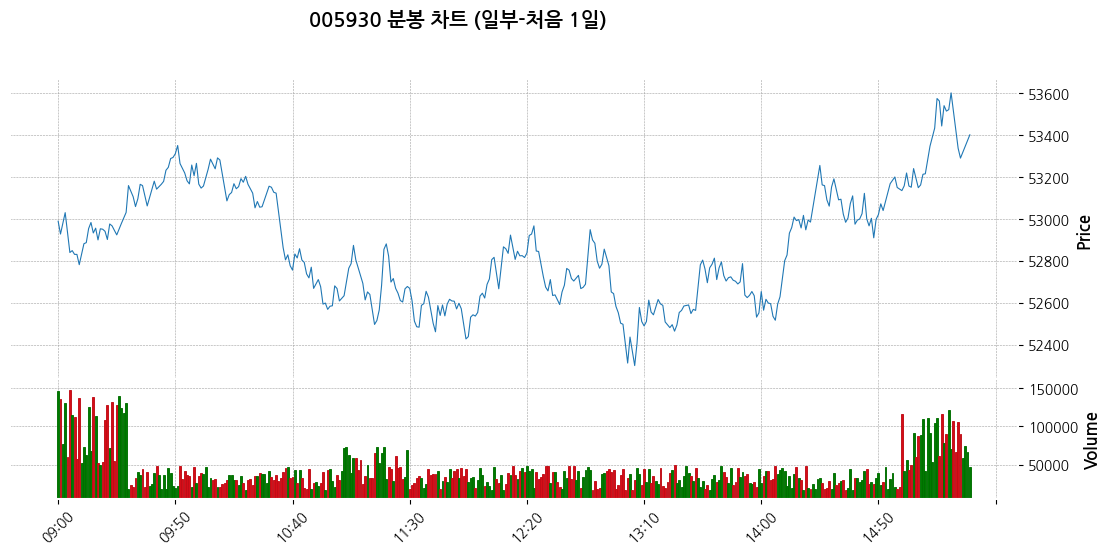

In [25]:
mpf.plot(
    df.head(cfg.sys.minutes_per_day),
    type="line",
    volume=True, 
    style=MPF_STYLE,
    title=f"{bars[0].ticker} 분봉 차트 (일부-처음 1일)",
    figsize=(14,6)
)

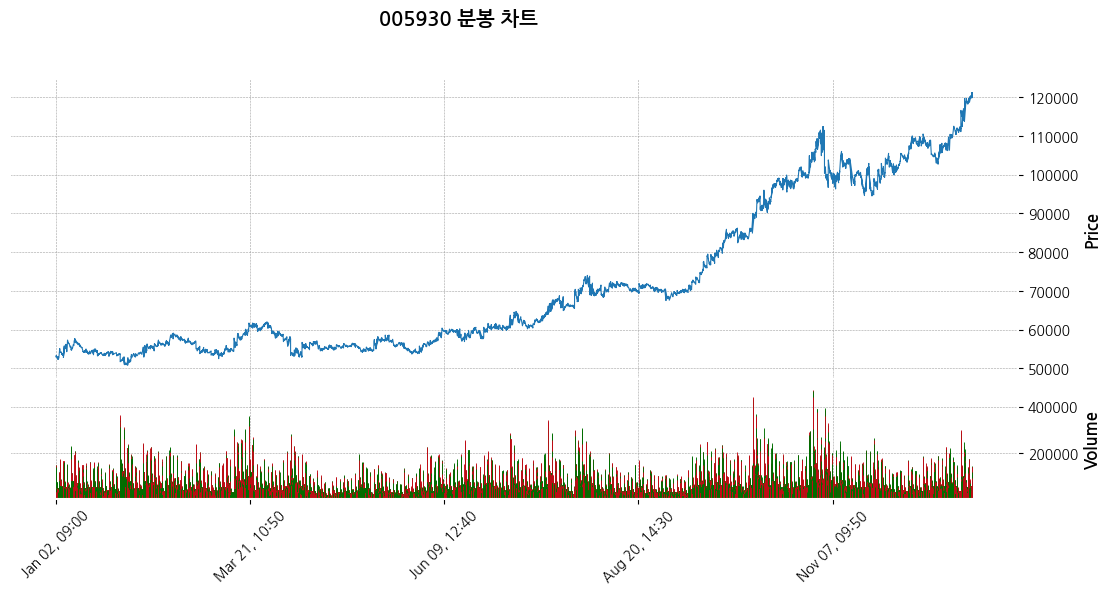

In [24]:
mpf.plot(
    df,
    type="line",
    volume=True, 
    style=MPF_STYLE,
    title=f"{bars[0].ticker} 분봉 차트",
    figsize=(14,6)
)

In [20]:
def my_chart(title: str, df: pd.DataFrame) -> None:
    mpf.plot(
        df, type="candle", volume=True, style=MPF_STYLE,
        title=title, figsize=(14,6)
    )

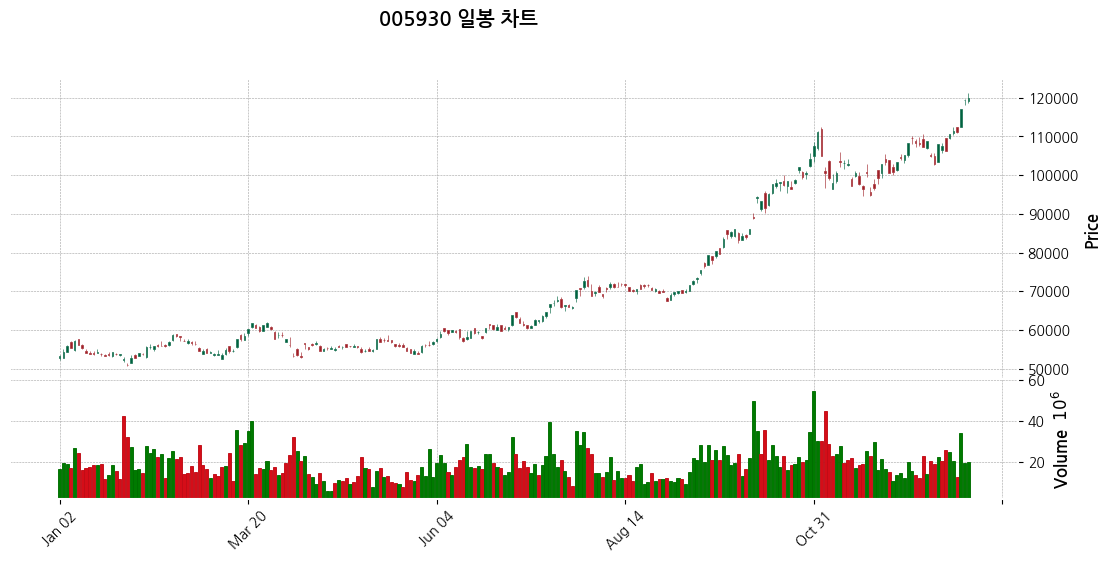

In [21]:
df_daily = df.resample("B").agg({
    "open": "first", 
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}).dropna()

my_chart(f"{bars[0].ticker} 일봉 차트", df_daily)

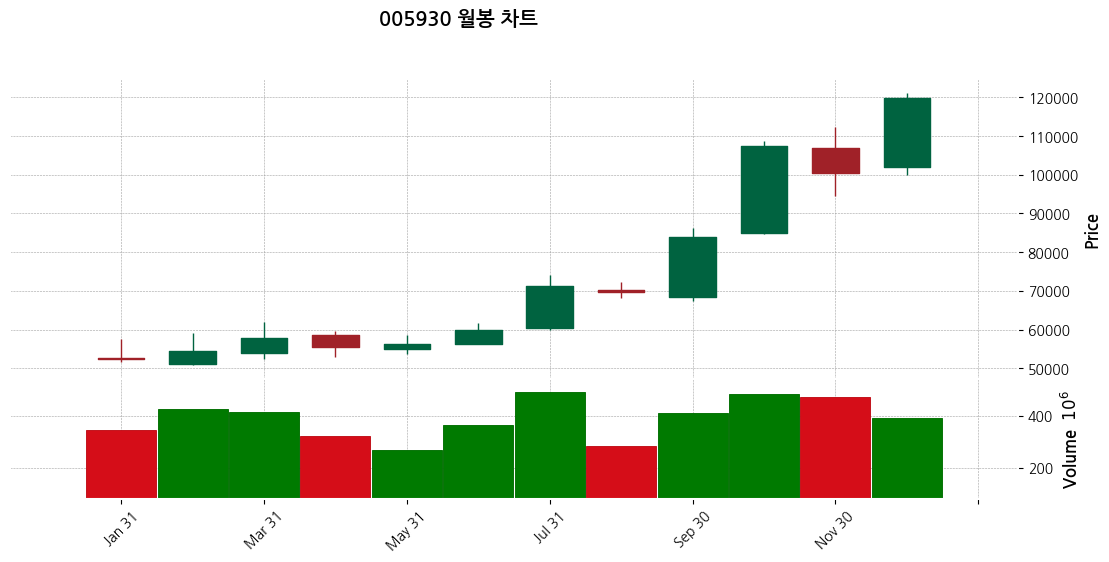

In [22]:
df_monthly = df.resample("ME").agg({
    "open": "first", 
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}).dropna()

my_chart(f"{bars[0].ticker} 월봉 차트", df_monthly)

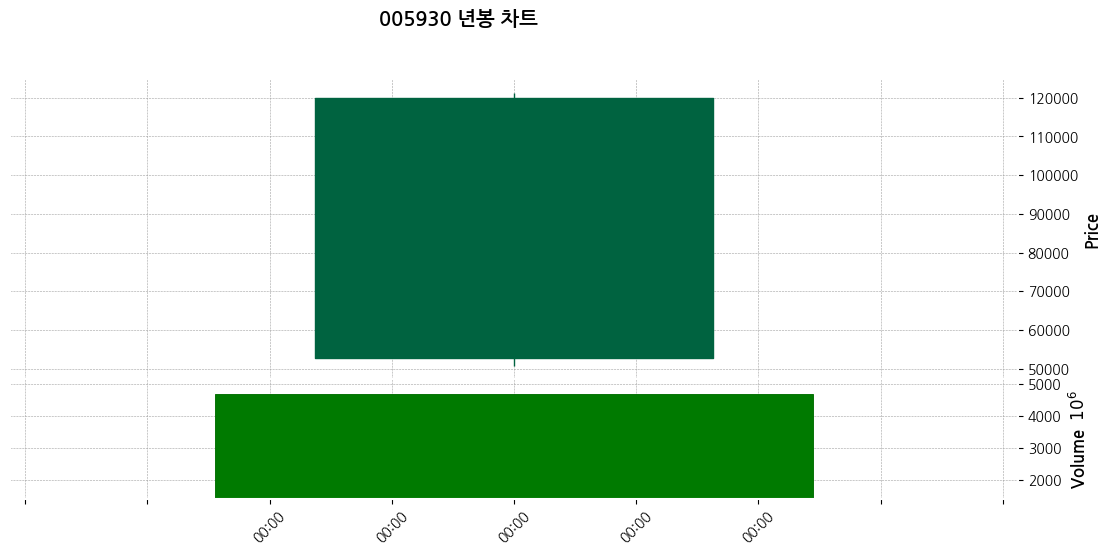

In [23]:
df_yearly = df.resample("YE").agg({
    "open": "first", 
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}).dropna()

my_chart(f"{bars[0].ticker} 년봉 차트", df_yearly)